<a href="https://colab.research.google.com/github/srujith2006/QuantumCircuitsWithIBMcomposure/blob/main/teleportation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f7baf8460f29e36c17e17f7a7d4646f72a5de51b0c7150538b4591db578df0bf
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip install qiskit-community-textbook

ERROR: Could not find a version that satisfies the requirement qiskit-community-textbook (from versions: none)
ERROR: No matching distribution found for qiskit-community-textbook


In [ ]:
import numpy as np
from qiskit import QuantumCircuit,QuantumRegister,quantum_info
from qiskit.visualization import plot_bloch_multivector,plot_histogram,array_to_latex

In [ ]:
from qiskit.circuit import ClassicalRegister
qr=QuantumRegister(3,name='q')
crz=ClassicalRegister(1,name='crz')
crx=ClassicalRegister(1,name='crx')


In [ ]:
def create_bell_pair(qc,a,b):
  qc.h(a)
  qc.cx(a,b)


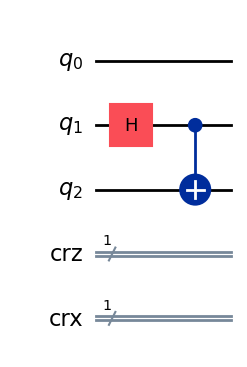

In [ ]:
circuit = QuantumCircuit(qr,crz,crx)
create_bell_pair(circuit,1,2)
circuit.draw('mpl')

In [ ]:
def alice_gates(qc,a,b):
  qc.cx(a,b)
  qc.h(a)

Step-2

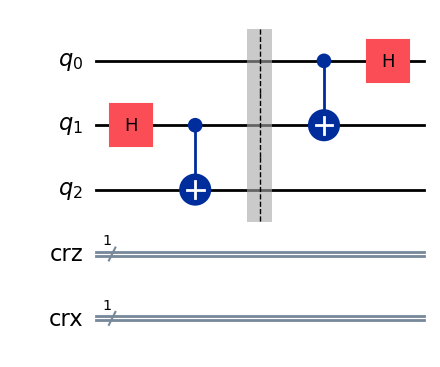

In [ ]:
circuit.barrier()
alice_gates(circuit,0,1)
circuit.draw('mpl')

Step-3

In [ ]:
def measure_send(qc,a,b):
  qc.barrier()
  qc.measure(a,0)
  qc.measure(b,0)

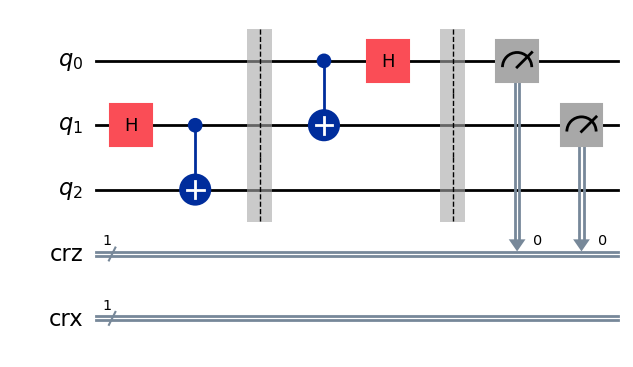

In [ ]:
measure_send(circuit,0,1)
circuit.draw('mpl')

Step-4

In [ ]:
def bob_gate(qc,qubit,crz,crx):
  qc.x(qubit).c_if(crx,1)
  qc.z(qubit).c_if(crz,1)

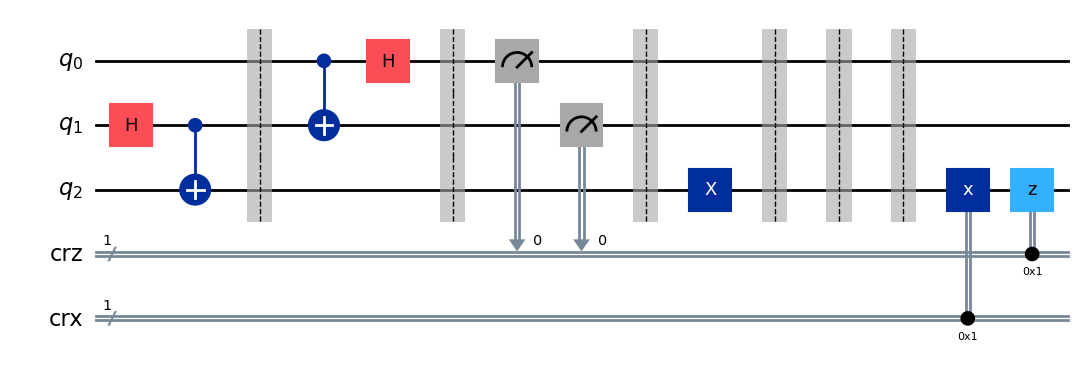

In [ ]:
circuit.barrier()

# Redefining bob_gate locally to fix the error in this cell's execution
from qiskit.circuit import Gate, QuantumCircuit, ClassicalRegister

def bob_gate(qc: QuantumCircuit, qubit: int, crz: ClassicalRegister, crx: ClassicalRegister):
  # Create a generic X gate and set its condition
  x_gate = Gate('x', 1, [])
  x_gate.condition = (crx, 1)
  qc.append(x_gate, [qubit])

  # Create a generic Z gate and set its condition
  z_gate = Gate('z', 1, [])
  z_gate.condition = (crz, 1)
  qc.append(z_gate, [qubit])

bob_gate(circuit,2,crz,crx)
circuit.draw('mpl')

Testing protocol

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_21859/3632414564.py:2: SyntaxWarning: invalid escape sequence '\p'
  display(array_to_latex(psi,prefix="|\psi\rangle="))


<IPython.core.display.Latex object>

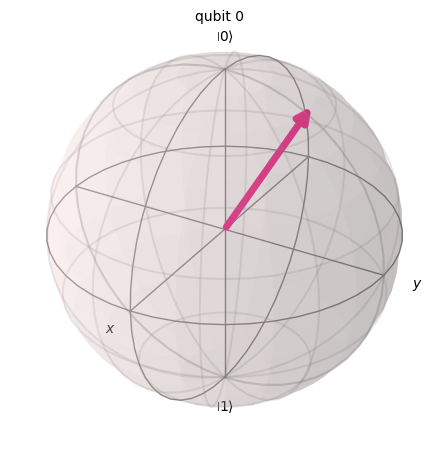

In [ ]:
psi=quantum_info.random_statevector(2)
display(array_to_latex(psi,prefix="|\psi\rangle="))
plot_bloch_multivector(psi)

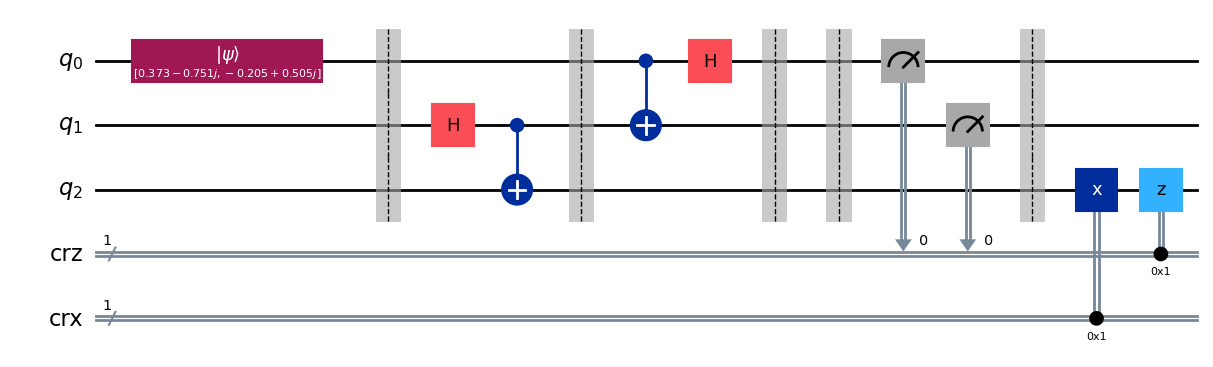

In [ ]:
qr=QuantumRegister(3,name='q')
crz=ClassicalRegister(1,name='crz')
crx=ClassicalRegister(1,name='crx')
qc=QuantumCircuit(qr,crz,crx)
qc.initialize(psi,[0])
qc.barrier()
create_bell_pair(qc,1,2)
qc.barrier()
alice_gates(qc,0,1)
qc.barrier()
measure_send(qc,0,1)
qc.barrier()
bob_gate(qc,2,crz,crx)
qc.draw('mpl')